**Imports**

In [11]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from keras.optimizers import Adam


**Deliverable 1: Data Loading and Preprocessing**

Step 1.1: Load CSV file

In [12]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Had initial problems with setting up correct environment; checking to see if correct Python version is running (3.11 for tensor flow)

In [13]:
print(sys.executable)
print(sys.version)

/Users/fionac./nlpcv/tf-venv/bin/python
3.11.4 (v3.11.4:d2340ef257, Jun  6 2023, 19:15:51) [Clang 13.0.0 (clang-1300.0.29.30)]


In [14]:
num_classes = 25
# 24 classes (a-z excluding j&z), needing 25 in order for 24 to be a valid index
input_shape = (28, 28, 1)
# 28 by 28 pixels, one channel bc grayscale image

#split train and test sets
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

Step 1.2: Normalize pixel values to [0,1]

In [15]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

#reshape 
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#ensuring images have correct shape
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


I displayed a few samples of the training dataset, in order to understand the features of the data I was working with.

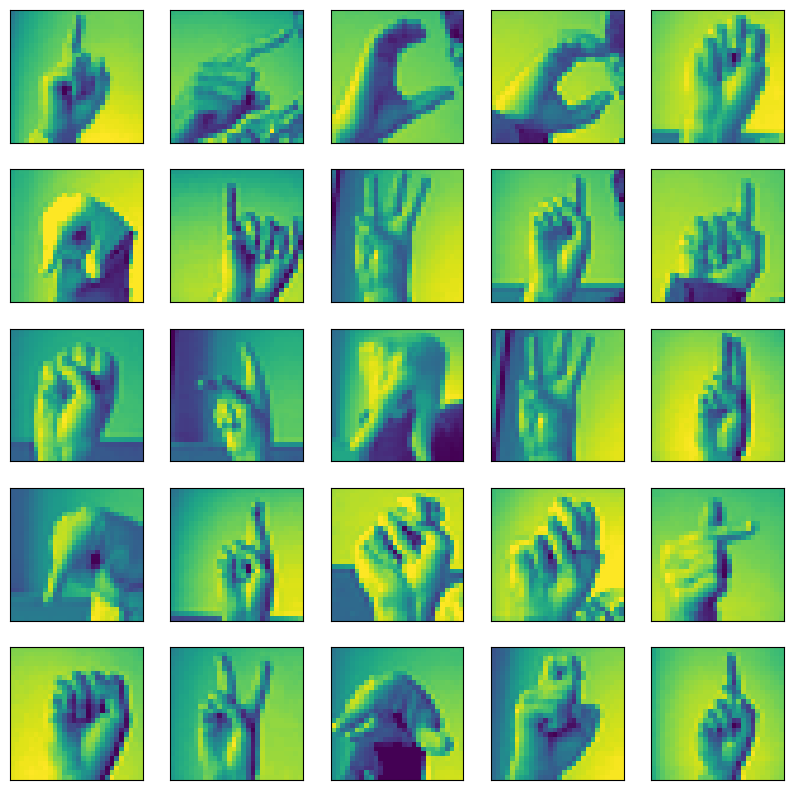

In [16]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]))
plt.show()
# view samples of ASL signs

Step 1.3: Creating validation split from train set

In [17]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# stratify with y_train to make sure class distribution matches original dataset
print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (21964, 28, 28, 1)
Val: (5491, 28, 28, 1)
Test: (7172, 28, 28, 1)


**Deliverable 2: CNN Architectures**

Step 2.1: Baseline CNN architecture

In [18]:
model_base = tf.keras.Sequential(
    [
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax"),

    ]
)
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │        25,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,617 (353.97 KB)

 Trainable params: 90,617 (353.97 KB)

 Non-trainable params: 0 (0.00 B)

Step 2.2: Enhanced CNN architecture - VGG-style Network 

In [19]:
#vggnet model
model_vgg = tf.keras.Sequential(
    [
        # first block
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        # 3,3 kernel is small enough to capture details of this dataset
        # padding =same keeps the output at 28,28 size so spatial info isn't lost
        # relu sets any negative values to zero; nonlinearity
        #regularization helps overfitting
        layers.BatchNormalization(),
        # normalizes output for each batch;stabilizes training
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # second block
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        #decided only to do 2 blocks because dataset isn't very large, so going super deep in layers wouldn't benefit this model
        # model with simplifying layers starting at 16 instead of 32 ran in around 4 minutes, while before it was running in 6-7 mins"

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),

    ]
)
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,033 (1.80 MB)

 Trainable params: 470,393 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

Step 3.3: Justify design choices
- I chose to implement a VGG-style network to increase the depth of the model and enhance feature extraction. This type of neural network works especially well for classification based tasks, which aligns with goal of this model to correctly depict what letter in the ASL alphabet is presented in each image. 

**Deliverable 3: Training, Testing, and Evaluation**

In [20]:
batch_size = 80
epochs = 15

model_base.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_vgg.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [21]:
history_base = model_base.fit(x_train, y_train, batch_size=80, epochs=15, validation_data=(x_val, y_val))

Epoch 1/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6242 - loss: 1.2387 - val_accuracy: 0.9297 - val_loss: 0.2159
Epoch 2/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9751 - loss: 0.0834 - val_accuracy: 0.9903 - val_loss: 0.0307
Epoch 3/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9985 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 1.0000 - loss: 9.6942e-04 - val_accuracy: 1.0000 - val_loss: 6.3167e-04
Epoch 5/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 1.0000 - loss: 5.0658e-04 - val_accuracy: 1.0000 - val_loss: 4.1488e-04
Epoch 6/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 1.0000 - loss: 3.3843e-04 - val_accuracy: 1.0000 - val_loss: 2.8027e-04
Epoch 7/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 1.0000 - loss: 2.2080e-04 - val_accuracy: 1.0000 - val_loss: 2.0659e-04
Epoch 8/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy:

In [22]:
score = model_base.evaluate(x_test, y_test, verbose=0)
print("Base model test loss:", score[0])
print("Base model test accuracy:", score[1])

Base model test loss: 0.5500743389129639
Base model test accuracy: 0.9071388840675354


In [23]:
early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
# stops training when val loss starts increasing
history_vgg = model_vgg.fit(x_train, y_train, batch_size=80, epochs=15, validation_data=(x_val, y_val), callbacks=early)
#baseline model with batch size of 128 and epochs of 100 took 21 mins to run

Epoch 1/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.8376 - loss: 0.6421 - val_accuracy: 0.1191 - val_loss: 3.2200
Epoch 2/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.9934 - loss: 0.0896 - val_accuracy: 0.9980 - val_loss: 0.0853
Epoch 3/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.9985 - loss: 0.0595 - val_accuracy: 1.0000 - val_loss: 0.0433
Epoch 4/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step - accuracy: 0.9993 - loss: 0.0509 - val_accuracy: 1.0000 - val_loss: 0.0407
Epoch 5/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.9994 - loss: 0.0459 - val_accuracy: 1.0000 - val_loss: 0.0383
Epoch 6/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 28s 101ms/step - accuracy: 0.9998 - loss: 0.0407 - val_accuracy: 0.9998 - val_loss: 0.0364
Epoch 7/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.9984 - loss: 0.0432 - val_accuracy: 0.9998 - val_loss: 0.0405
Epoch 8/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.9995 - loss: 0.0406 -

In [24]:
score = model_vgg.evaluate(x_test, y_test, verbose=0)
print("VGG model test loss:", score[0])
print("VGG model test accuracy:", score[1])
# baseline model had test loss of 0.93 and test acc of 0.84
# new model had test loss of 1.23 and test acc of 0.88
# adding drop out helped so much! 0.94 accuracy and test loss of 0.33 (0.3 dropout)
# even better with 0.5 dropout! 0.96 acc and test loss of 0.18
# 0.97 acc with adding 0.0001 l2 regularization
# 0.973 acc and .136 test loss woith dropout of 0.3!

VGG model test loss: 0.19038641452789307
VGG model test accuracy: 0.9696040153503418


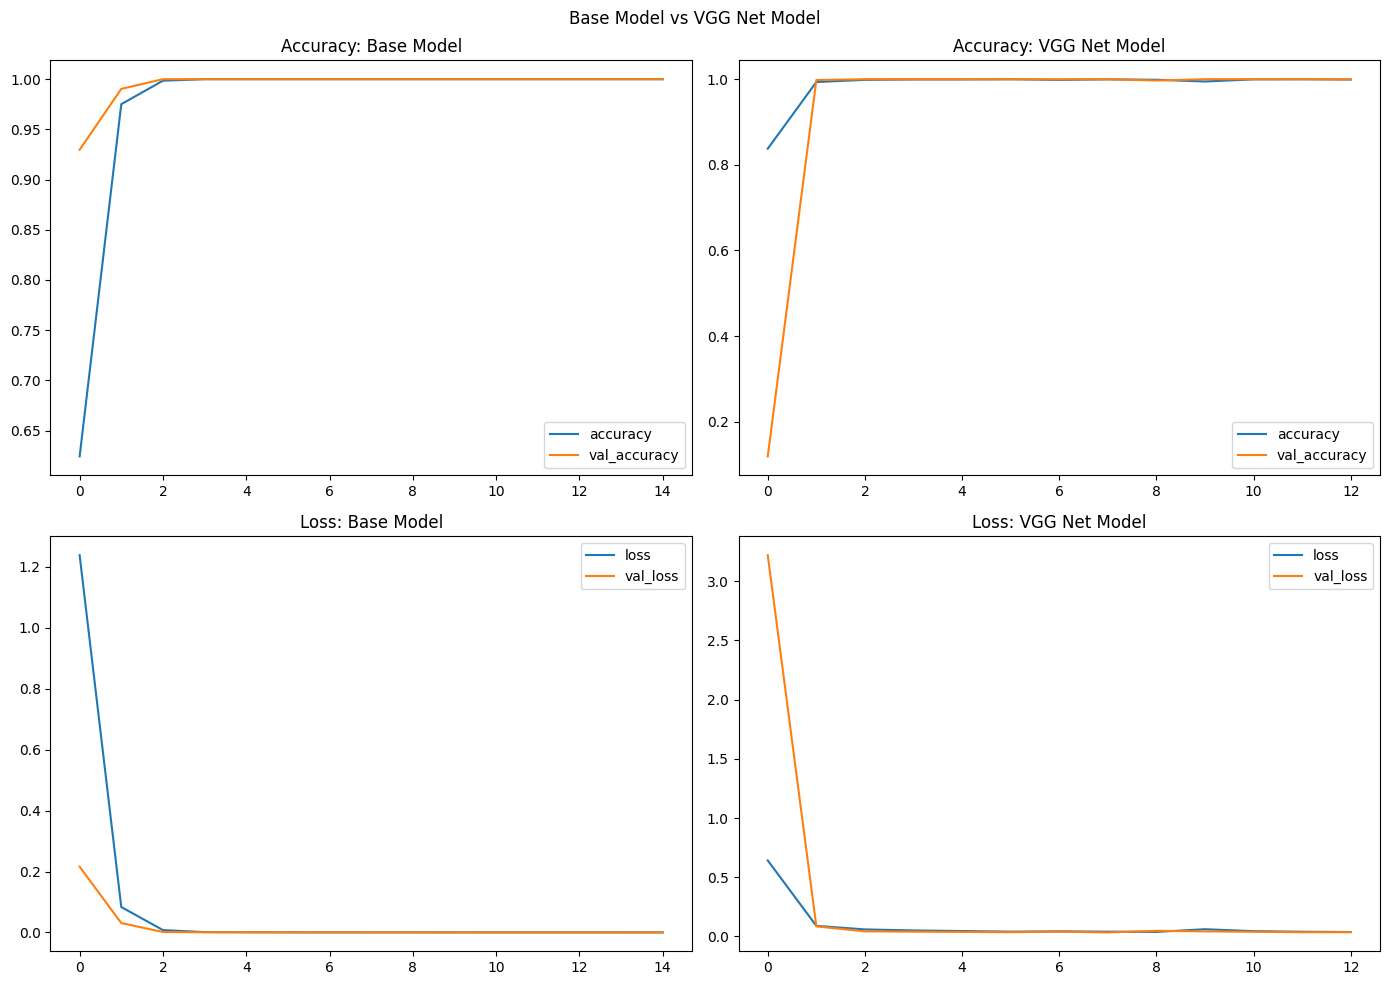

225/225 - 1s - 5ms/step - accuracy: 0.9071 - loss: 0.5501
225/225 - 2s - 9ms/step - accuracy: 0.9696 - loss: 0.1904


In [25]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Base Model vs VGG Net Model")

ax[0,0].plot(history_base.history['accuracy'], label='accuracy')
ax[0,0].plot(history_base.history['val_accuracy'], label = 'val_accuracy')
ax[0,0].set_title('Accuracy: Base Model')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(history_vgg.history['accuracy'], label='accuracy')
ax[0,1].plot(history_vgg.history['val_accuracy'], label = 'val_accuracy')
ax[0,1].set_title('Accuracy: VGG Net Model')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(history_base.history['loss'], label='loss')
ax[1,0].plot(history_base.history['val_loss'], label = 'val_loss')
ax[1,0].set_title('Loss: Base Model')
ax[1,0].legend(loc='upper right')

ax[1,1].plot(history_vgg.history['loss'], label='loss')
ax[1,1].plot(history_vgg.history['val_loss'], label = 'val_loss')
ax[1,1].set_title('Loss: VGG Net Model')
ax[1,1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = model_base.evaluate(x_test,  y_test, verbose=2)
test_loss, test_acc = model_vgg.evaluate(x_test,  y_test, verbose=2)

**Deliverable 3: Training, Testing, and Evaluation**

In [26]:
y_pred_probs = model_vgg.predict(x_test)
# gives probs
y_pred_labels = np.argmax(y_pred_probs, axis=1)
# predicted class labels

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [27]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_labels))
print("\nClassification report:")
print(classification_report(y_test, y_pred_labels))

Confusion matrix:
[[331   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 432   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0 310   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 245   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0 498   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 348   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0  20 416   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 267   0   0   0   0   0   0   0   0   0
    0   0   0   0   0  21]
 [  0   0   0   0   0   0   0   1   0 310   0   0   0   0   0   0   0  20

In [28]:
prec = precision_score(y_test, y_pred_labels, average="macro")
print("Precision score:", prec)
rec = recall_score(y_test, y_pred_labels, average="macro")
print("Recall score:", rec)
f1 = f1_score(y_test, y_pred_labels, average="macro")
print("F1 score:", f1)

Precision score: 0.9724080110793091
Recall score: 0.9694569397136176
F1 score: 0.969170489658695


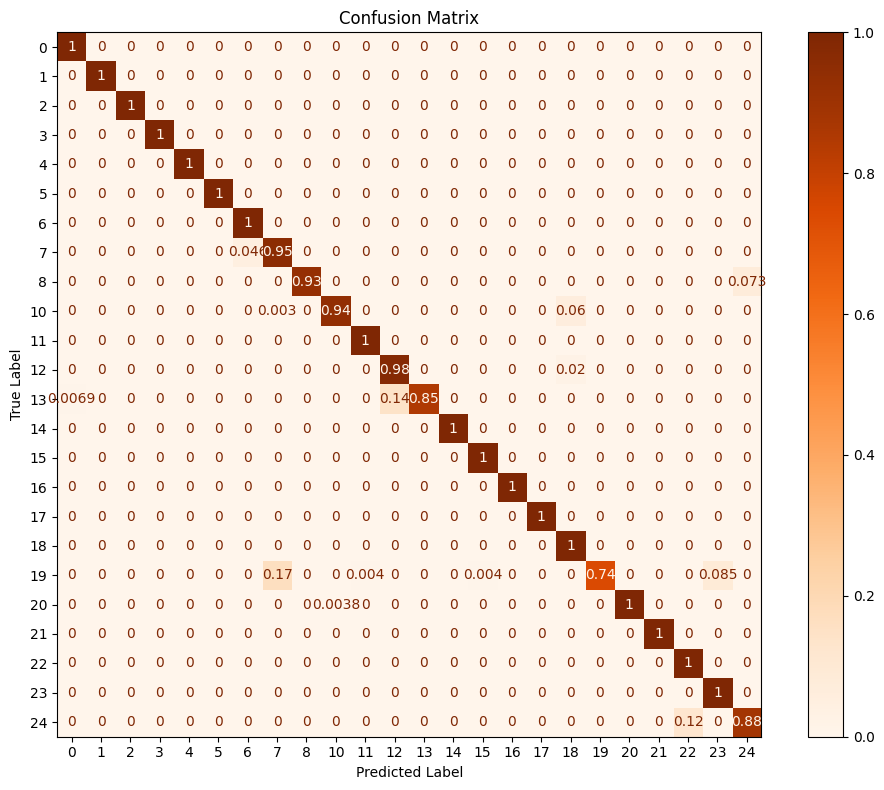

In [29]:
labels = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred_labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='Oranges', colorbar=True, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()


#classes 6 (g) and 7 (h) are harder to classify, often classified as class 19
#class 17 (r) as class 10 (k)
#overall classes 19, 10, 7 have the most errors or higher missclassification rates
#class 13 and class 19 and 24

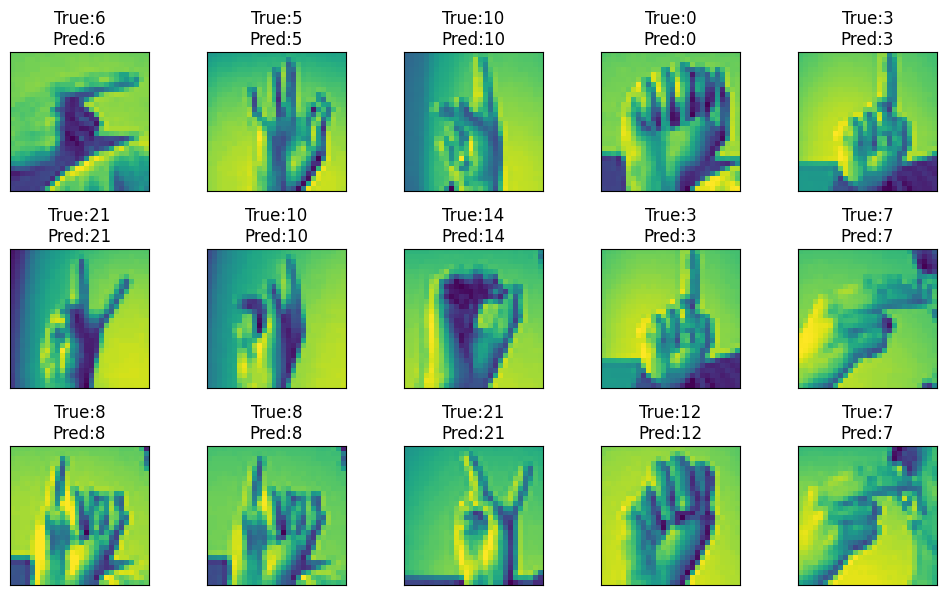

In [30]:
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_test[i,:,:,:]))
    plt.title(f"True:{y_test[i]}\nPred:{y_pred_labels[i]}")
    plt.tight_layout()
plt.show()